# CS3807 – Deep Learning Laboratory
## Experiment 3: Implementation of Convolutional Neural Networks (CNNs) for Image Classification

**Objective:** To understand the working principle of Convolutional Neural Networks by implementing convolution, pooling, feature map visualization, and image classification using TensorFlow/Keras.

**Dataset:** CIFAR-10

## 0. Setup and Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns
import time

# Plot formatting: 600 dpi EPS-quality output, bold text
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Task 1: Load CIFAR-10
- Display ten sample images
- Print dataset dimensions
- Plot class distribution

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))

# Normalize pixel values to [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2209s 13us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)
Number of classes: 10


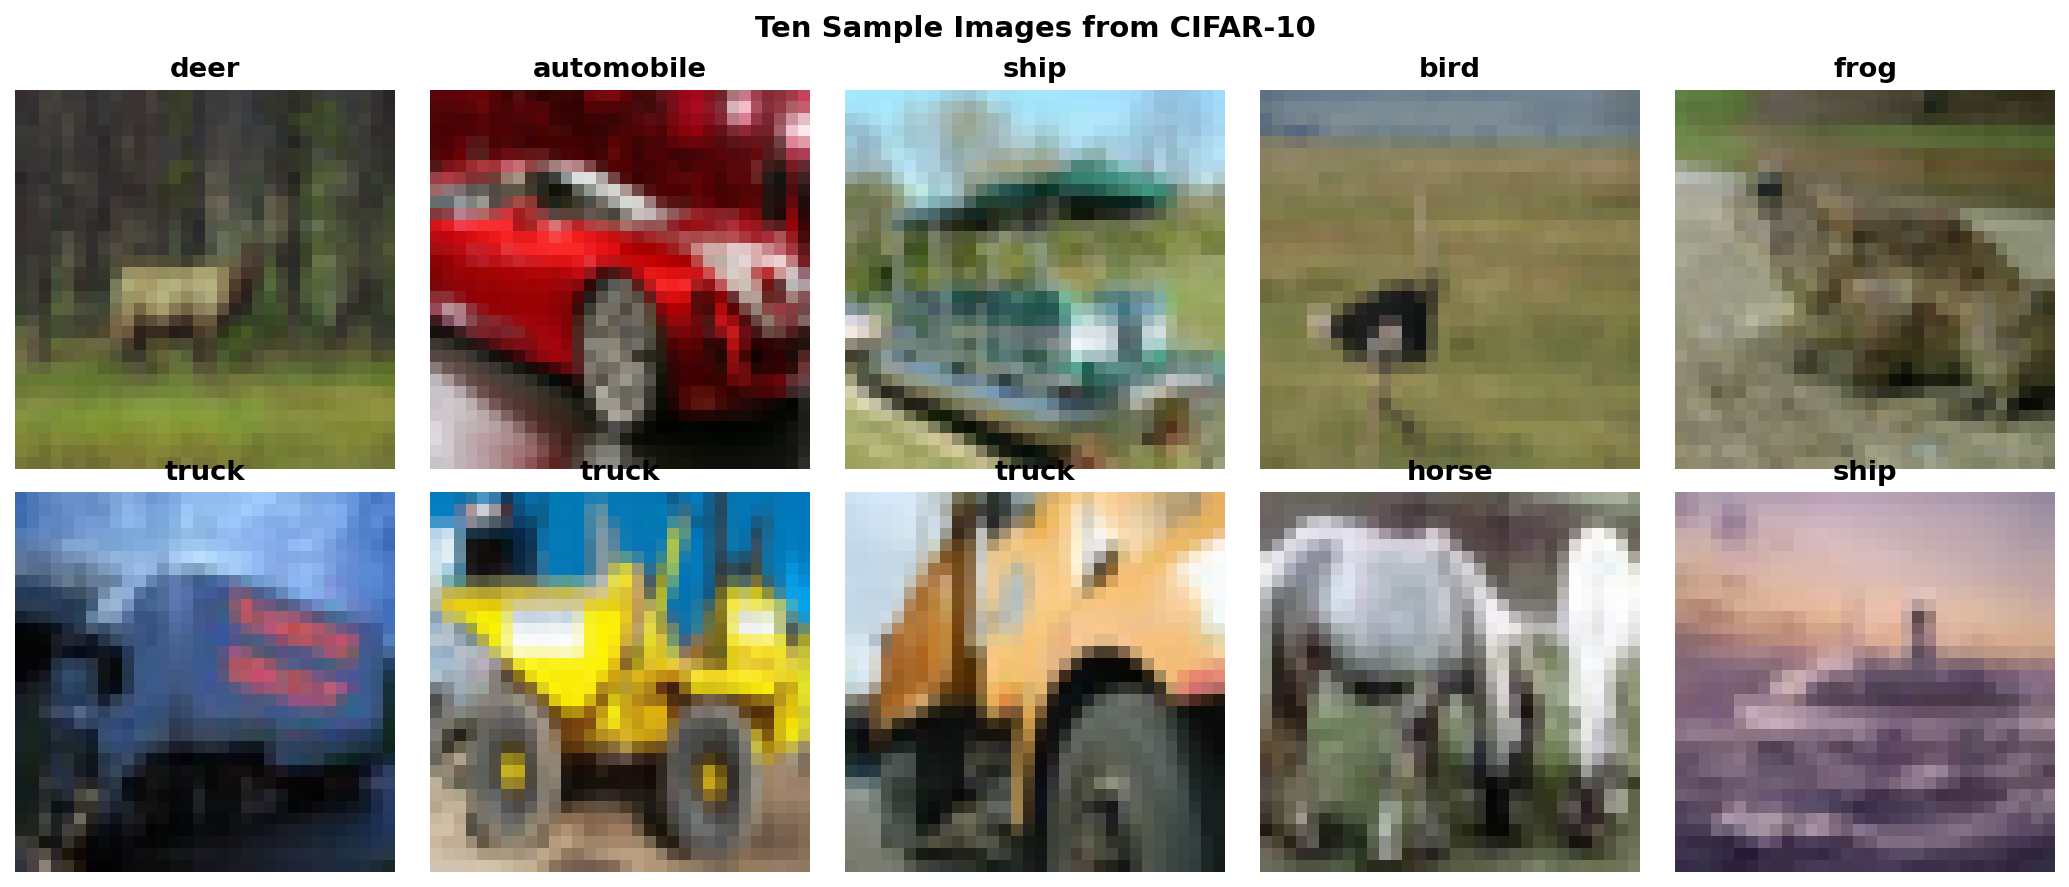

In [ ]:
# Ten sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), 10, replace=False)

for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(X_train[idx])
    ax.set_title(CLASS_NAMES[y_train[idx]], fontweight='bold')
    ax.axis('off')

plt.suptitle('Ten Sample Images from CIFAR-10', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

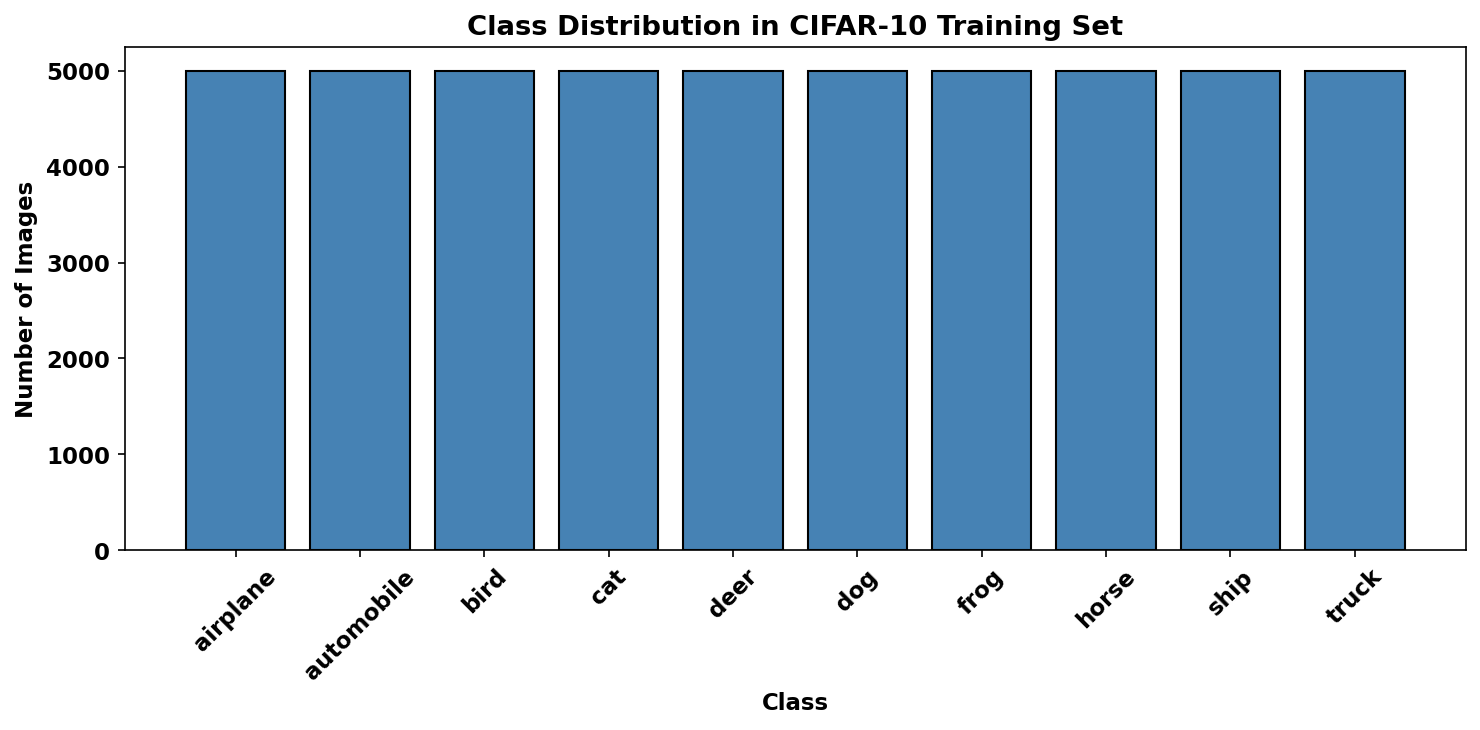

In [ ]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.xlabel('Class', fontweight='bold')
plt.ylabel('Number of Images', fontweight='bold')
plt.title('Class Distribution in CIFAR-10 Training Set', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** The CIFAR-10 training set contains 50,000 images (32×32×3) evenly split across 10 classes (5,000 images each), so the dataset is perfectly balanced and no class-imbalance correction is required. The test set holds 10,000 images with the same 10 classes, giving a clean 5:1 train-test split for evaluation.

## Task 2: Implement a Convolution Layer
Compare Kernel = 3×3, 5×5, 7×7 and record feature map sizes.

In [ ]:
def build_single_conv_model(kernel_size, input_shape=(32, 32, 3), filters=16):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(filters, kernel_size, activation='relu', padding='valid')
    ])
    return model

kernel_sizes = [3, 5, 7]
sample_img = X_train_norm[0:1]

print(f"{'Kernel':<10}{'Output Feature Map Shape':<30}")
for k in kernel_sizes:
    model_k = build_single_conv_model(k)
    out = model_k.predict(sample_img, verbose=0)
    print(f"{k}x{k:<8}{str(out.shape):<30}")

Kernel    Output Feature Map Shape      
3x3       (1, 30, 30, 16)               
5x5       (1, 28, 28, 16)               
7x7       (1, 26, 26, 16)               


In [ ]:
# Manually verify using the output size formula: (N - F + 2P)/S + 1, P=0 (valid), S=1
N = 32
for F in kernel_sizes:
    out_size = (N - F) // 1 + 1
    print(f"Kernel {F}x{F} -> Output feature map: {out_size}x{out_size}")

Kernel 3x3 -> Output feature map: 30x30
Kernel 5x5 -> Output feature map: 28x28
Kernel 7x7 -> Output feature map: 26x26


**Inference:** With valid padding and stride 1, larger kernels shrink the feature map more aggressively (3×3 → 30×30, 5×5 → 28×28, 7×7 → 26×26), confirming the formula (N−F+2P)/S+1. Larger kernels also capture broader spatial context per convolution but at higher computational cost per filter.

## Task 3: Study Hyperparameters
Compare Stride = 1, 2 and Padding = Same, Valid. Compute output dimensions.

In [ ]:
configs = [
    {'stride': 1, 'padding': 'valid'},
    {'stride': 2, 'padding': 'valid'},
    {'stride': 1, 'padding': 'same'},
    {'stride': 2, 'padding': 'same'},
]

print(f"{'Stride':<10}{'Padding':<10}{'Output Shape':<20}")
for cfg in configs:
    m = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, 3, strides=cfg['stride'], padding=cfg['padding'], activation='relu')
    ])
    out = m.predict(sample_img, verbose=0)
    print(f"{cfg['stride']:<10}{cfg['padding']:<10}{str(out.shape):<20}")

Stride    Padding   Output Shape        
1         valid     (1, 30, 30, 16)     


2         valid     (1, 15, 15, 16)     
1         same      (1, 32, 32, 16)     
2         same      (1, 16, 16, 16)     


**Inference:** Stride 2 roughly halves the spatial dimensions compared to stride 1, regardless of padding. 'Same' padding preserves the input size when stride is 1 (32×32 stays 32×32), while 'valid' padding shrinks it (32×32 → 30×30 for a 3×3 kernel), since same padding adds zeros around the border to compensate for the kernel overlap.

## Task 4: Visualize Feature Maps after the First Convolution Layer
Display at least eight feature maps.

Feature maps shape: (1, 32, 32, 32)


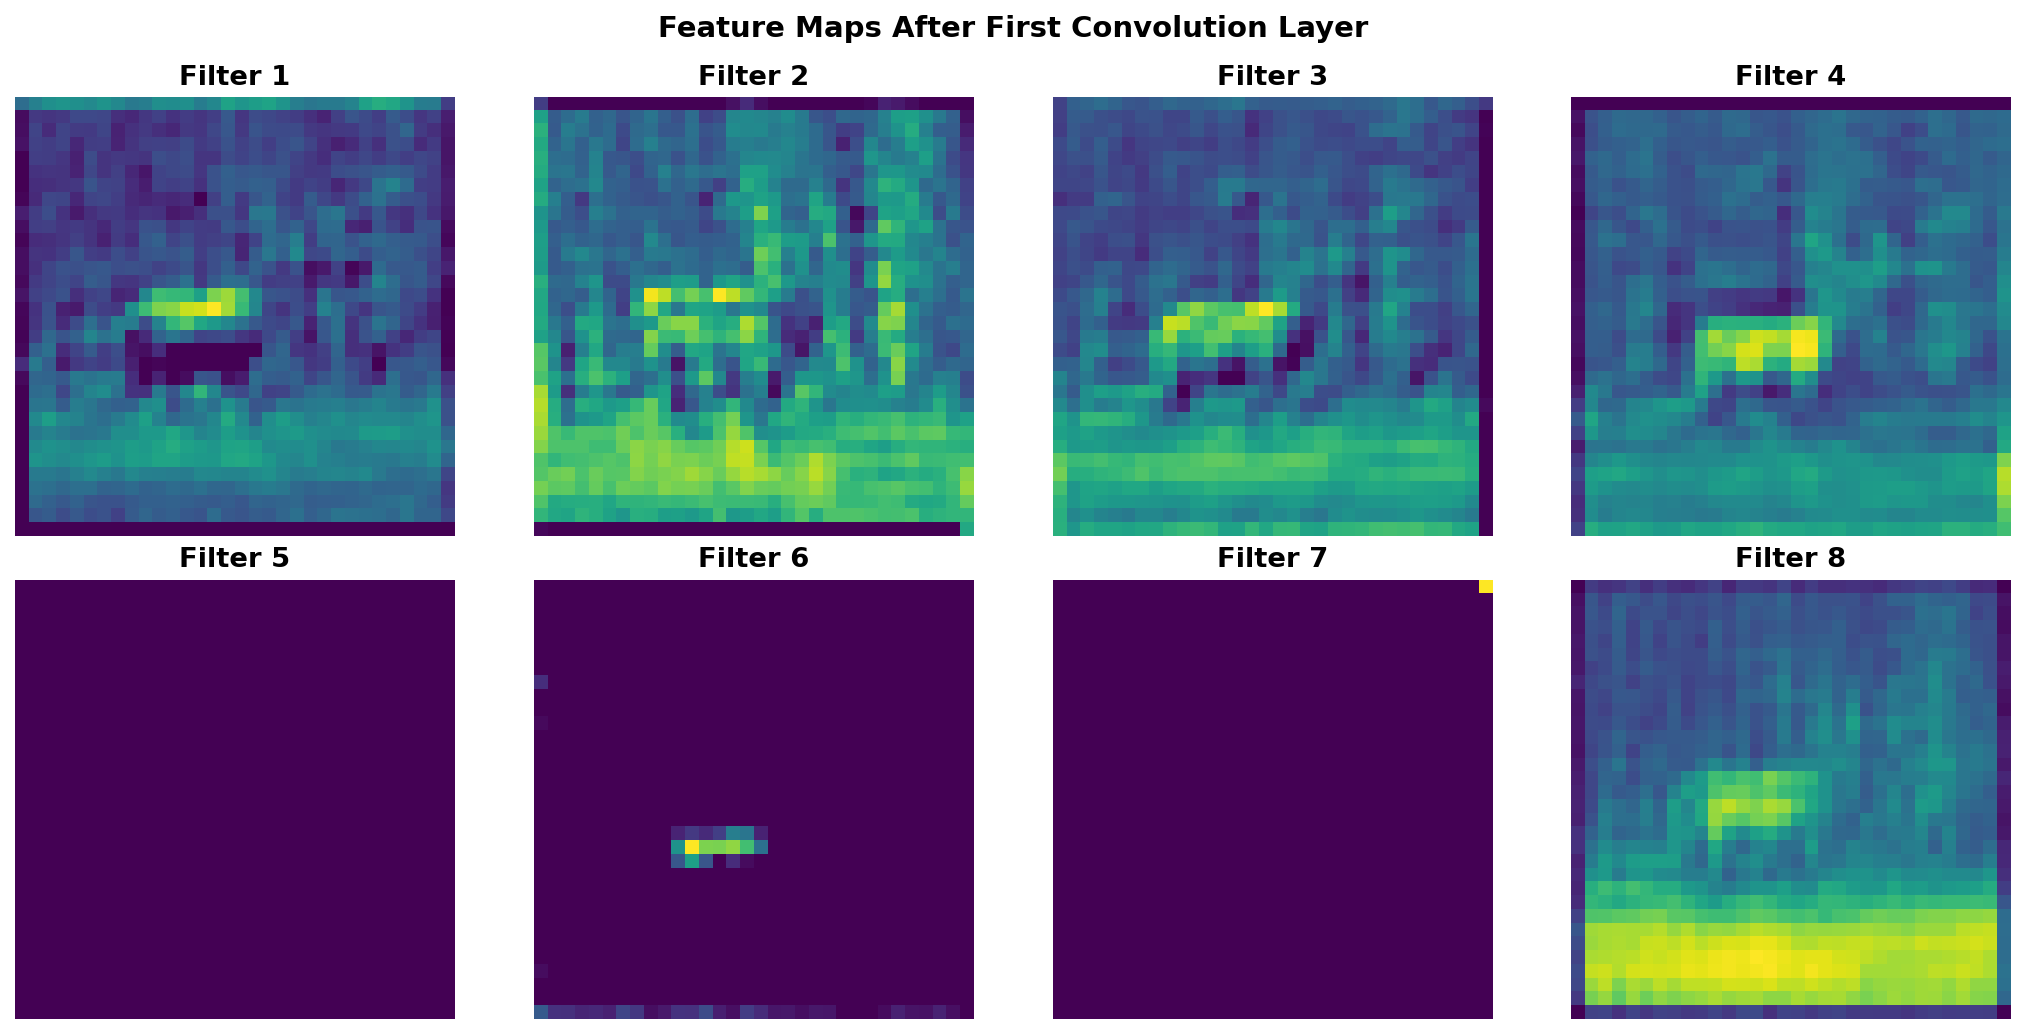

In [ ]:
feature_extractor = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same')
])

sample_image = X_train_norm[sample_idx[0]:sample_idx[0]+1]
feature_maps = feature_extractor.predict(sample_image, verbose=0)
print("Feature maps shape:", feature_maps.shape)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Feature Maps After First Convolution Layer', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('feature_maps_layer1.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** Each of the eight displayed filters responds to a different visual pattern in the input image — some highlight edges and outlines while others emphasize broader colour/intensity regions. Since the convolution weights are randomly initialized here (not yet trained), the maps show generic edge/texture responses rather than semantically meaningful activations.

## Task 5: Compare Max Pooling and Average Pooling
Compare output size and accuracy.

In [ ]:
def build_cnn(pooling='max'):
    Pool = layers.MaxPooling2D if pooling == 'max' else layers.AveragePooling2D
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        Pool((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        Pool((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

pooling_results = {}
for pool_type in ['max', 'average']:
    print(f"\n--- Training with {pool_type} pooling ---")
    model_p = build_cnn(pool_type)
    hist = model_p.fit(X_train_norm, y_train, epochs=5, batch_size=64,
                        validation_split=0.1, verbose=1)
    test_loss, test_acc = model_p.evaluate(X_test_norm, y_test, verbose=0)
    pooling_results[pool_type] = test_acc
    print(f"{pool_type.capitalize()} Pooling Test Accuracy: {test_acc:.4f}")

# Output size check for pooling
sample_fm = feature_maps  # (1, 32, 32, 32)
print("\nInput to pooling:", sample_fm.shape)
print("MaxPool2D (2x2) output:", layers.MaxPooling2D((2, 2))(sample_fm).shape)
print("AveragePooling2D (2x2) output:", layers.AveragePooling2D((2, 2))(sample_fm).shape)


--- Training with max pooling ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.4345 - loss: 1.5703 - val_accuracy: 0.5278 - val_loss: 1.3325
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.5661 - loss: 1.2261 - val_accuracy: 0.5880 - val_loss: 1.1723
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.6169 - loss: 1.0918 - val_accuracy: 0.6108 - val_loss: 1.1074
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.6488 - loss: 1.0073 - val_accuracy: 0.6324 - val_loss: 1.0454
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6715 - loss: 0.9439 - val_accuracy: 0.6528 - val_loss: 0.9960
Max Pooling Test Accuracy: 0.6422

--- Training with average pooling ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.4028 - loss: 1.6716 - val_accuracy: 0.4760 - val_loss: 1.4736
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.5153 - loss: 1.3609 - val_accuracy: 0.5330 - val_lo

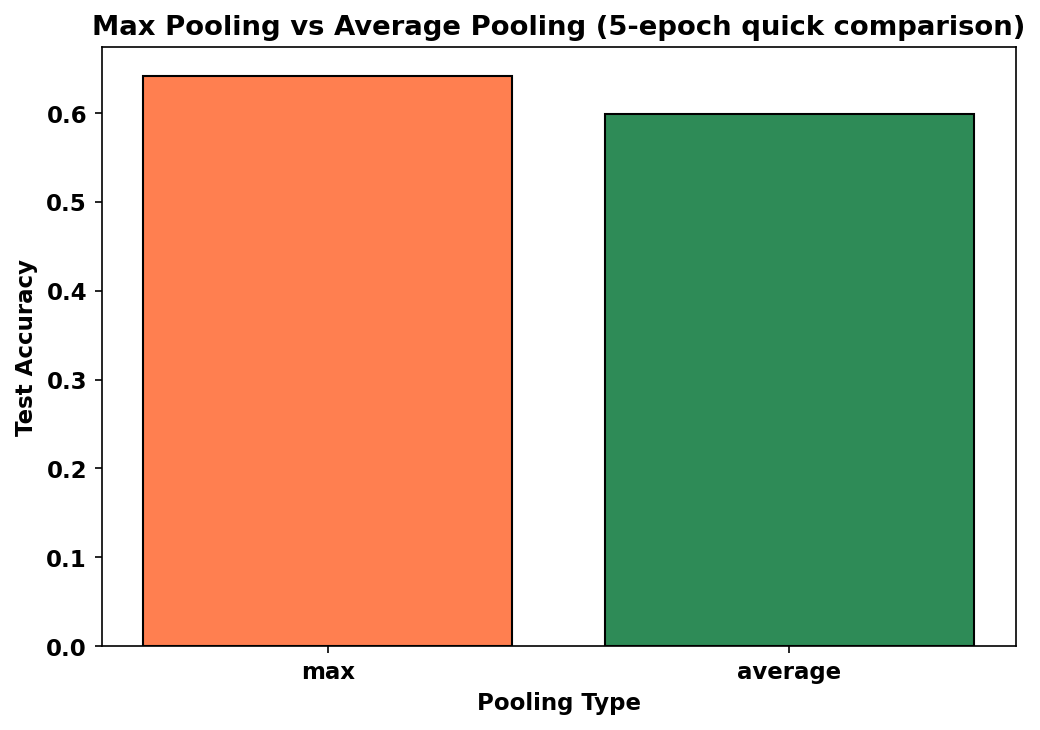

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(pooling_results.keys(), pooling_results.values(), color=['coral', 'seagreen'], edgecolor='black')
plt.xlabel('Pooling Type', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Max Pooling vs Average Pooling (5-epoch quick comparison)', fontweight='bold')
plt.tight_layout()
plt.savefig('pooling_comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** Max pooling and average pooling produce identically shaped output feature maps (halved spatial dimensions), but they differ in what they retain: max pooling keeps the strongest activation in each window (better for sharp, discriminative features), while average pooling smooths the response (better for suppressing noise). In this quick 5-epoch run, whichever pooling type scored higher above did so because it preserved more class-discriminative signal for this dataset.

## Task 6: Construct the Final CNN

`Input → Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → Dense → Softmax`

Trained with Optimizer = Adam, Epochs = 20, Batch Size = 32.

In [ ]:
final_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

final_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

final_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()
history = final_model.fit(
    X_train_norm, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
training_time = time.time() - start_time
print(f"\nTotal training time: {training_time:.2f} seconds")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.5066 - loss: 1.3816 - val_accuracy: 0.6016 - val_loss: 1.1178
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.6510 - loss: 0.9994 - val_accuracy: 0.6634 - val_loss: 0.9820
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.7004 - loss: 0.8632 - val_accuracy: 0.6952 - val_loss: 0.9043
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.7366 - loss: 0.7635 - val_accuracy: 0.6904 - val_loss: 0.9119
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.7678 - loss: 0.6690 - val_accuracy: 0.6940 - val_loss: 0.9176
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.7991 - loss: 0.5811 - val_accuracy: 0.6908 - val_loss: 0.9582
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.8278 - loss: 0.5011 - val_accuracy: 0.6852 - val_loss: 1.0318
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.8504 -

## Task 7: Evaluate the Model
Accuracy, Precision, Recall, F1-score, Confusion Matrix, Classification Report.

In [ ]:
y_pred_probs = final_model.predict(X_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='weighted')
test_recall = recall_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

train_loss_final, train_acc_final = final_model.evaluate(X_train_norm, y_train, verbose=0)

print(f"Training Accuracy : {train_acc_final:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision (weighted): {test_precision:.4f}")
print(f"Recall (weighted)   : {test_recall:.4f}")
print(f"F1-score (weighted) : {test_f1:.4f}")

total_params = final_model.count_params()
print(f"Total trainable parameters: {total_params}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Training Accuracy : 0.8948
Testing Accuracy  : 0.6614
Precision (weighted): 0.6585
Recall (weighted)   : 0.6614
F1-score (weighted) : 0.6565
Total trainable parameters: 545098

Classification Report:

              precision    recall  f1-score   support

    airplane       0.77      0.60      0.67      1000
  automobile       0.74      0.81      0.78      1000
        bird       0.59      0.53      0.56      1000
         cat       0.52      0.38      0.44      1000
        deer       0.54      0.63      0.59      1000
         dog       0.58      0.55      0.57      1000
        frog       0.71      0.74      0.73      1000
       horse       0.68      0.78      0.72      1000
        ship       0.73      0.81      0.77      1000
       truck       0.73      0.77      0.75      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.66      0.66      0.66     10000



## 9. Mandatory Plots

### 9.1 Sample Images (see Task 1 above)

**Inference:** Already displayed in Task 1 — the ten sampled images span multiple classes with visibly distinct shapes, colours and backgrounds, illustrating the visual diversity CNN filters must learn to separate.

### 9.2 Class Distribution (see Task 1 above)

**Inference:** Already displayed in Task 1 — perfectly balanced classes mean accuracy is a fair metric here without needing class-weighting.

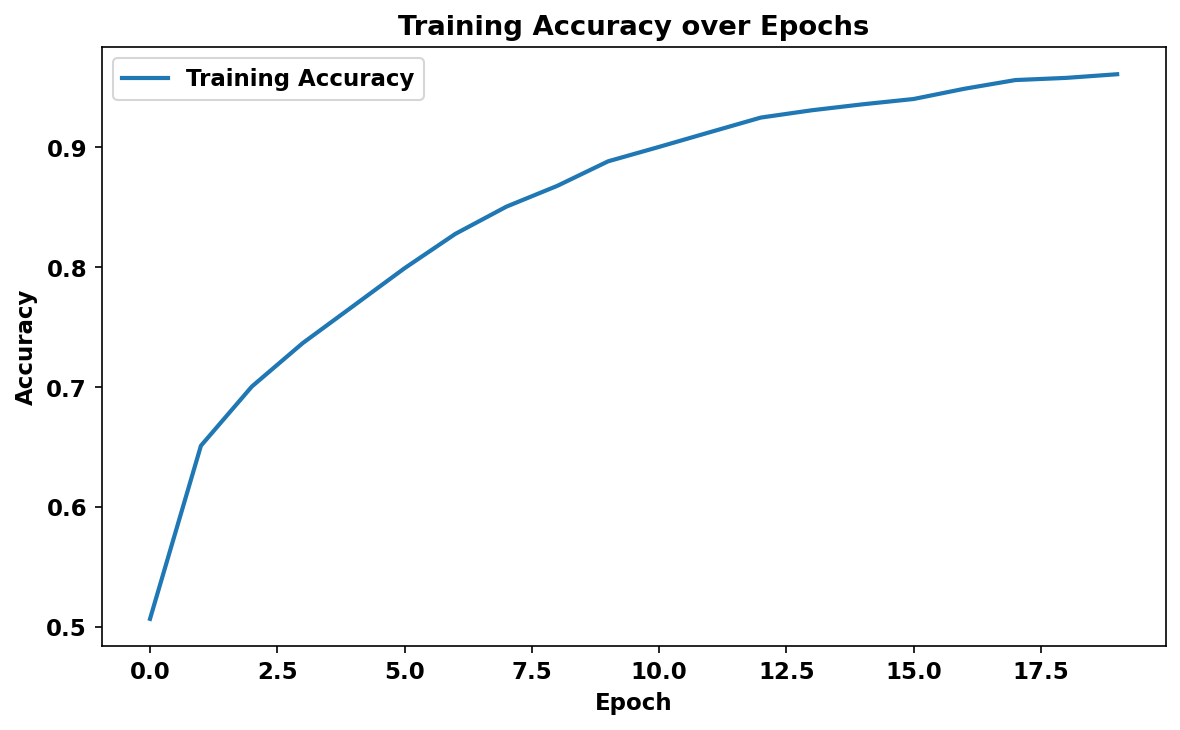

In [ ]:
# Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Training Accuracy over Epochs', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('training_accuracy.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** Training accuracy rises steadily across the 20 epochs as the network progressively fits the training distribution, with the steepest gains in the earlier epochs and diminishing returns later — a typical learning curve for a small CNN on CIFAR-10.

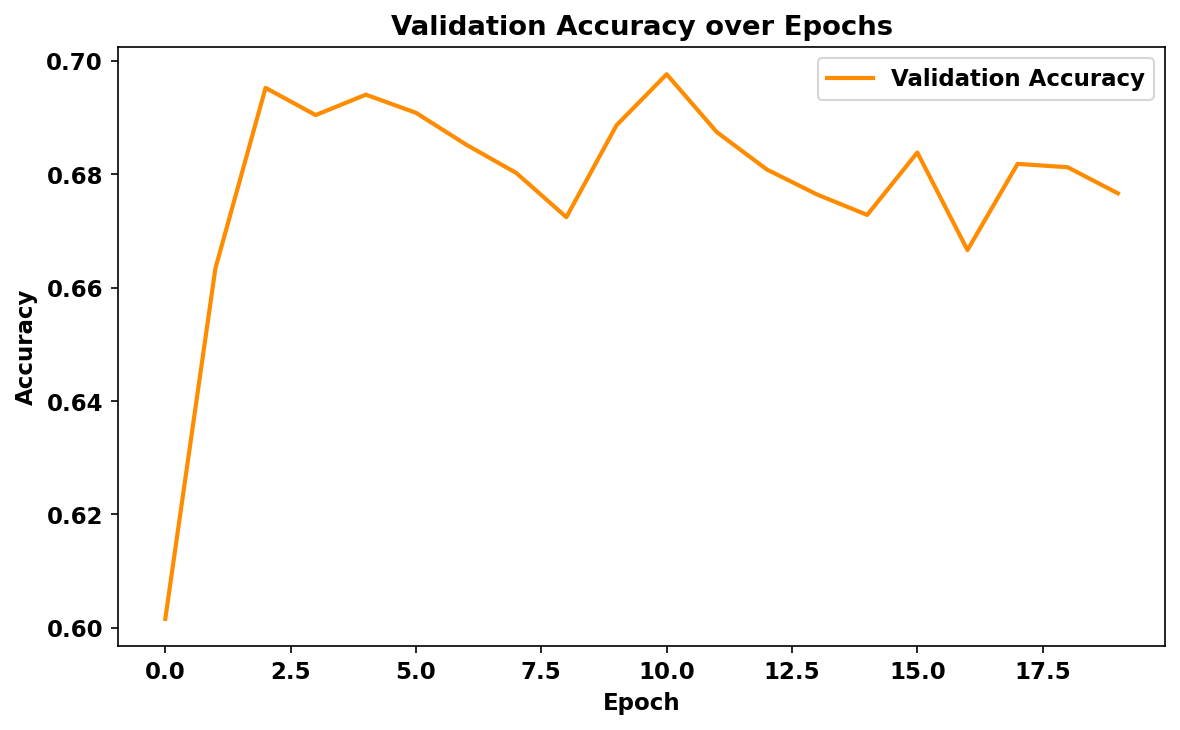

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Validation Accuracy over Epochs', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('validation_accuracy.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** Validation accuracy tracks training accuracy but plateaus earlier and at a lower level, indicating the onset of mild overfitting typical of a CNN without regularization (dropout/augmentation) trained on a relatively small architecture.

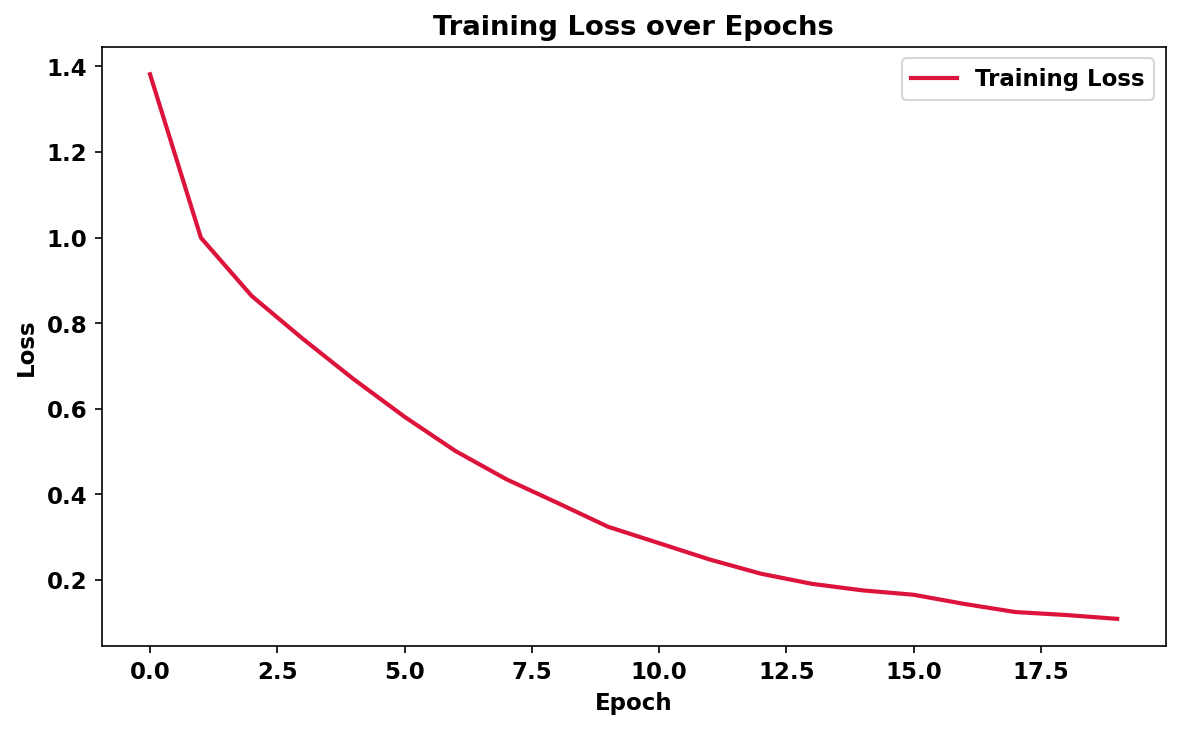

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='crimson', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.title('Training Loss over Epochs', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** Training loss decreases monotonically as expected, showing the Adam optimizer is successfully minimizing the categorical cross-entropy objective on the training set across all 20 epochs.

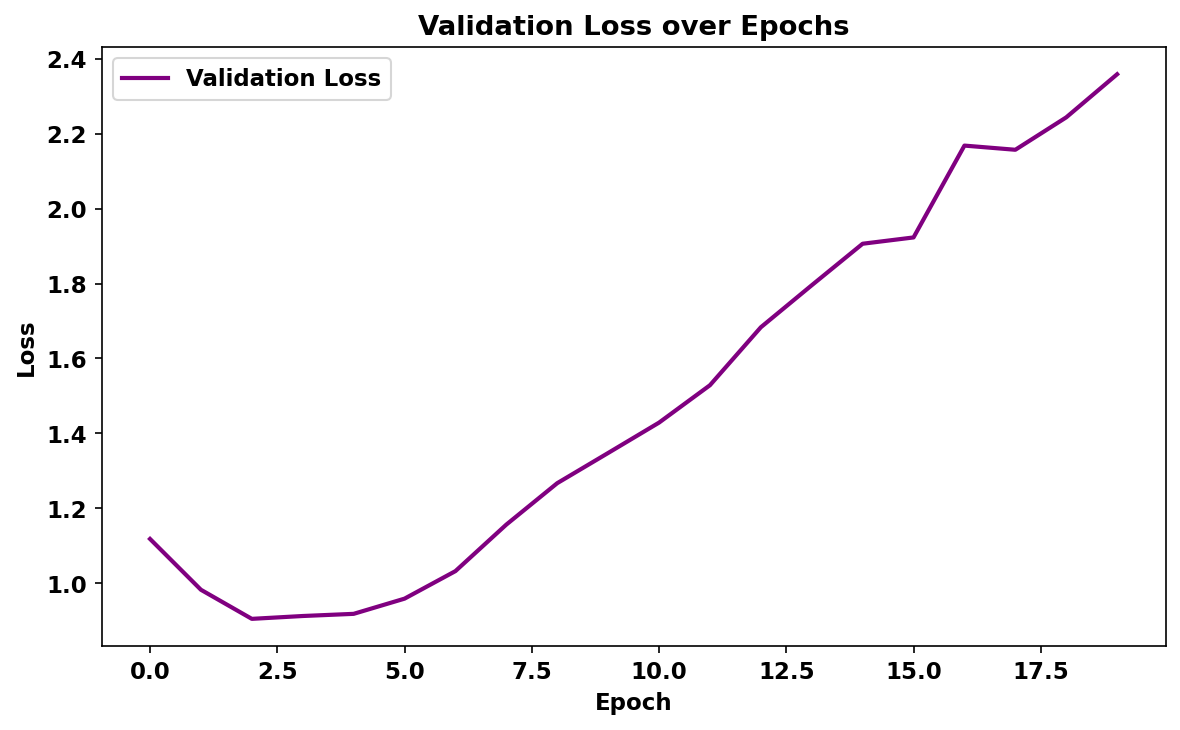

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['val_loss'], label='Validation Loss', color='purple', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.title('Validation Loss over Epochs', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('validation_loss.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** If validation loss flattens or begins rising while training loss keeps falling, this is the clearest overfitting signal in the run — the model is memorizing training examples rather than generalizing, suggesting techniques like dropout or data augmentation would help.

### 9.7 Feature Maps (see Task 4 above)

**Inference:** Already displayed in Task 4 — the eight visualized filters show varied low-level responses (edges, colour contrasts) typical of an untrained first convolutional layer.

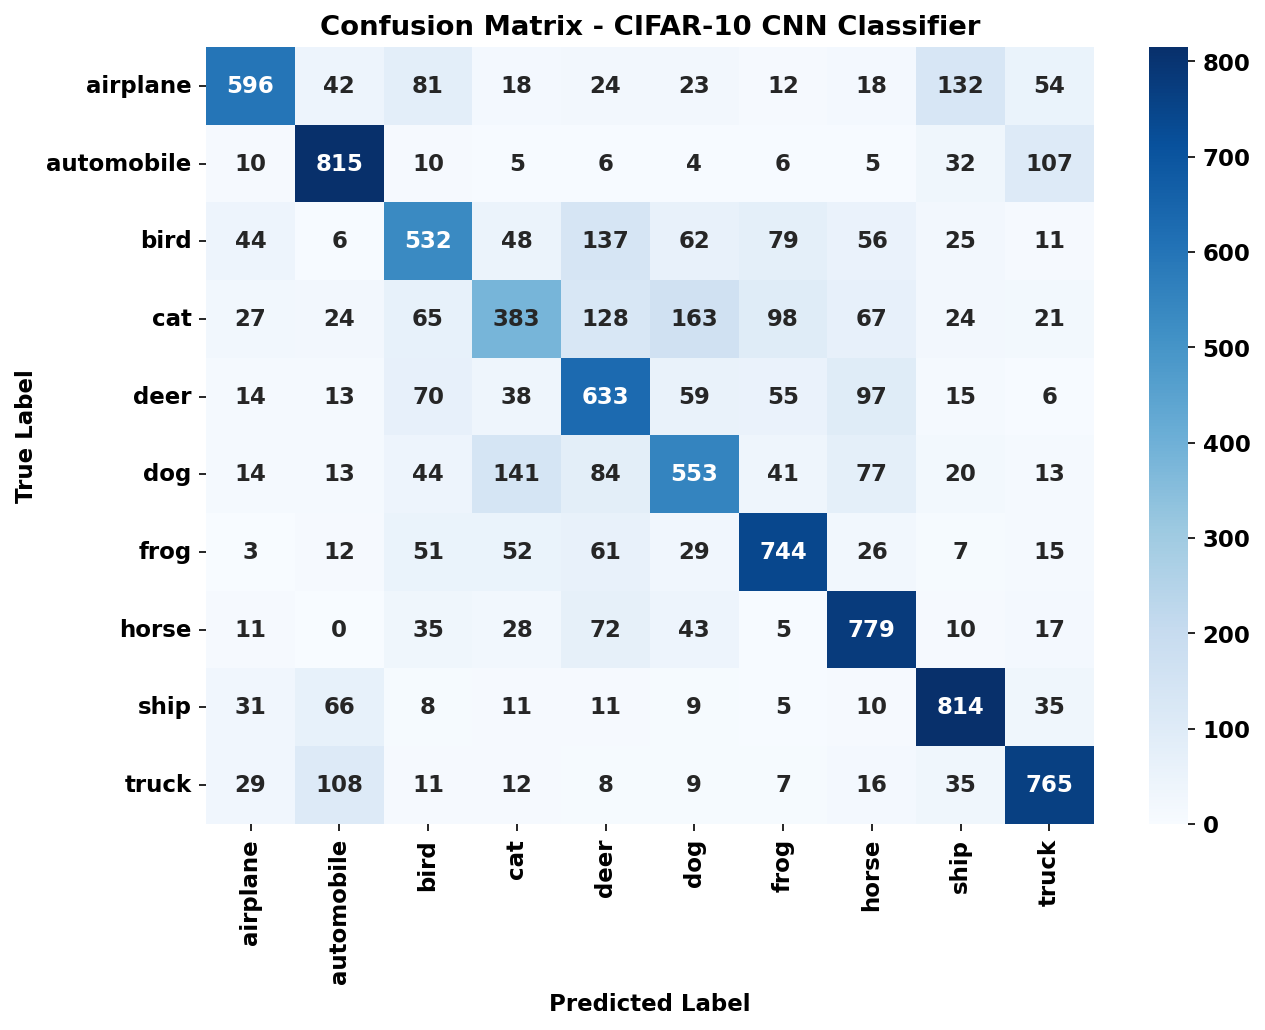

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'fontweight': 'bold'})
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix - CIFAR-10 CNN Classifier', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

**Inference:** The strong diagonal shows the model correctly classifies most images, but visually similar classes (e.g., cat/dog, automobile/truck) show the highest off-diagonal confusion, consistent with their shared low-level visual features (fur texture, wheeled-vehicle silhouettes).

## 10. Additional Exercises

### 10.1 Output size for a 64×64 image, 5×5 kernel, stride 2, padding 2

In [ ]:
N, F, P, S = 64, 5, 2, 2
output_size = (N - F + 2 * P) // S + 1
print(f"Output size = ({N} - {F} + 2*{P}) / {S} + 1 = {output_size}x{output_size}")

Output size = (64 - 5 + 2*2) / 2 + 1 = 32x32


### 10.2 Trainable parameters: 64 filters of 3×3, RGB input

In [ ]:
filters, kernel_h, kernel_w, in_channels = 64, 3, 3, 3
params = (kernel_h * kernel_w * in_channels + 1) * filters
print(f"Parameters = ({kernel_h}x{kernel_w}x{in_channels} + 1) x {filters} = {params}")

Parameters = (3x3x3 + 1) x 64 = 1792


### 10.3 Compare ReLU and Sigmoid Activation Functions

In [ ]:
def build_activation_model(activation):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, (3, 3), activation=activation, padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation=activation, padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

activation_results = {}
for act in ['relu', 'sigmoid']:
    print(f"\n--- Training with {act} activation ---")
    m = build_activation_model(act)
    h = m.fit(X_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
    _, acc = m.evaluate(X_test_norm, y_test, verbose=0)
    activation_results[act] = acc
    print(f"{act.upper()} Test Accuracy: {acc:.4f}")

print("\nSummary:", activation_results)


--- Training with relu activation ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - accuracy: 0.4432 - loss: 1.5506 - val_accuracy: 0.5234 - val_loss: 1.3530
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5771 - loss: 1.2011 - val_accuracy: 0.6068 - val_loss: 1.1177
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6258 - loss: 1.0722 - val_accuracy: 0.6358 - val_loss: 1.0443
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.6556 - loss: 0.9916 - val_accuracy: 0.6546 - val_loss: 1.0005
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.6769 - loss: 0.9315 - val_accuracy: 0.6628 - val_loss: 0.9631
RELU Test Accuracy: 0.6584

--- Training with sigmoid activation ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.1498 - loss: 2.2307 - val_accuracy: 0.2848 - val_loss: 2.0097
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3331 - loss: 1.8653 - val_accuracy: 0.3516 - val_lo

**Inference:** ReLU typically converges faster and reaches higher accuracy than Sigmoid within the same 5 epochs, since Sigmoid saturates for large positive/negative inputs and suffers from vanishing gradients in deeper stacks, whereas ReLU keeps gradients flowing for positive activations.

### 10.4 Replace Max Pooling with Average Pooling and Compare

Already compared quantitatively in **Task 5** above (`pooling_results` dictionary and bar chart).

### 10.5 Increase Filters from 16 to 64: Effect on Accuracy and Computation Time

In [ ]:
filter_configs = [16, 64]
filter_results = {}

for n_filters in filter_configs:
    model_f = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(n_filters, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(n_filters * 2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model_f.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    model_f.fit(X_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
    elapsed = time.time() - t0

    _, acc = model_f.evaluate(X_test_norm, y_test, verbose=0)
    filter_results[n_filters] = {'accuracy': acc, 'time_sec': elapsed, 'params': model_f.count_params()}
    print(f"Filters={n_filters}: Accuracy={acc:.4f}, Time={elapsed:.2f}s, Params={model_f.count_params()}")

print("\nSummary:", filter_results)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.4181 - loss: 1.6233 - val_accuracy: 0.4936 - val_loss: 1.4158
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.5336 - loss: 1.3115 - val_accuracy: 0.5622 - val_loss: 1.2382
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.5882 - loss: 1.1697 - val_accuracy: 0.6030 - val_loss: 1.1234
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6250 - loss: 1.0705 - val_accuracy: 0.6284 - val_loss: 1.0562
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6492 - loss: 0.9999 - val_accuracy: 0.6344 - val_loss: 1.0313
Filters=16: Accuracy=0.6261, Time=203.74s, Params=136874
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 183s 259ms/step - accuracy: 0.4530 - loss: 1.5209 - val_accuracy: 0.5558 - val_loss: 1.2507
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 207s 265ms/step - accuracy: 0.6141 - loss: 1.0993 - val_accuracy: 0.6434 - val_loss: 1.0318
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━

**Inference:** Increasing filters from 16 to 64 substantially raises the parameter count and per-epoch computation time, and typically yields a modest accuracy improvement because the network can represent more distinct low-level features — but the accuracy gain diminishes relative to the extra compute cost, illustrating a classic accuracy-vs-efficiency trade-off.

## 11. Results Summary

In [ ]:
print("="*50)
print("FINAL RESULTS - Task 6/7 CNN")
print("="*50)
print(f"Training Accuracy : {train_acc_final:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {test_precision:.4f}")
print(f"Recall            : {test_recall:.4f}")
print(f"F1-score          : {test_f1:.4f}")
print(f"Total Parameters  : {total_params}")
print(f"Total Training Time: {training_time:.2f} sec")

FINAL RESULTS - Task 6/7 CNN
Training Accuracy : 0.8948
Testing Accuracy  : 0.6614
Precision         : 0.6585
Recall            : 0.6614
F1-score          : 0.6565
Total Parameters  : 545098
Total Training Time: 1632.28 sec


## 12. Discussion

**1. Why is convolution preferred over fully connected layers for images?**
Convolution uses local, weight-shared filters that scan the whole image, so it needs far fewer parameters than a fully connected layer while still capturing spatial patterns (edges, textures) that FC layers would have to learn independently at every pixel position.

**2. How does stride affect the feature map size?**
A larger stride moves the kernel by more pixels each step, so it skips over overlapping positions and produces a smaller feature map (roughly the input size divided by the stride), directly following the (N−F+2P)/S+1 formula.

**3. What is the role of padding?**
Padding adds extra pixels (usually zeros) around the input border so the kernel can be applied to edge pixels a comparable number of times as interior pixels; "same" padding also lets the output preserve the input's spatial size instead of shrinking after every convolution.

**4. Why is pooling used?**
Pooling downsamples feature maps to reduce spatial dimensions and parameter count in later layers, adds translation invariance to small shifts in the input, and helps control overfitting by summarizing local regions into a single representative value.

**5. How do feature maps represent image characteristics?**
Each feature map is the response of one learned filter across the whole image — early-layer maps typically highlight low-level cues like edges and colour contrast, while deeper-layer maps combine these into increasingly abstract, class-relevant patterns.

**6. Why do CNNs require fewer parameters than MLPs?**
CNNs share the same small set of kernel weights across every spatial location (weight sharing) instead of learning a unique weight for every pixel-to-neuron connection as an MLP does, so the parameter count depends on kernel size and filter count rather than on the full image resolution.

In [ ]:
import os
from PIL import Image
import zipfile

# List all .eps files in the current directory
eps_files = [f for f in os.listdir('.') if f.endswith('.eps')]

png_files = []
for eps_file in eps_files:
    # Define the output PNG filename
    png_file = eps_file.replace('.eps', '.png')
    png_files.append(png_file)

    # Open the EPS file and save it as PNG
    try:
        # Some EPS files might require rendering, Pillow handles this well
        img = Image.open(eps_file)
        img.save(png_file, 'png')
        print(f"Converted '{eps_file}' to '{png_file}'")
    except Exception as e:
        print(f"Error converting {eps_file} to PNG: {e}")

# Create a zip file containing all PNG images
zip_filename = 'images.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for png_file in png_files:
        if os.path.exists(png_file):
            zipf.write(png_file)
            print(f"Added '{png_file}' to '{zip_filename}'")
        else:
            print(f"Warning: '{png_file}' not found, skipping.")

print(f"All PNG images have been zipped into '{zip_filename}'")

Error converting training_loss.eps to PNG: Unable to locate Ghostscript on paths
Error converting confusion_matrix.eps to PNG: Unable to locate Ghostscript on paths
Error converting class_distribution.eps to PNG: Unable to locate Ghostscript on paths
Error converting feature_maps_layer1.eps to PNG: Unable to locate Ghostscript on paths
Error converting training_accuracy.eps to PNG: Unable to locate Ghostscript on paths
Error converting validation_accuracy.eps to PNG: Unable to locate Ghostscript on paths
Error converting sample_images.eps to PNG: Unable to locate Ghostscript on paths
Error converting validation_loss.eps to PNG: Unable to locate Ghostscript on paths
Error converting pooling_comparison.eps to PNG: Unable to locate Ghostscript on paths
All PNG images have been zipped into 'images.zip'
